In [1]:
from google.colab import files
files.upload()  # upload kaggle.json (Kaggle → Account → API → Create New Token)

import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.config/kaggle/')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')
os.system('pip install kaggle -q')
os.system('kaggle datasets download -d sigfest/database-for-emotion-recognition-system-gameemo')
os.system('unzip -q database-for-emotion-recognition-system-gameemo.zip -d gameemo')
print('Dataset downloaded!')

# Check folder structure
for root, dirs, files_list in os.walk('gameemo'):




    level = root.replace('gameemo', '').count(os.sep)
    if level < 3:
        print(' ' * 2 * level + os.path.basename(root) + '/')
        for f in files_list[:3]:
            print(' ' * 2 * (level+1) + f)

Saving kaggle.json to kaggle.json
Dataset downloaded!
gameemo/
  GAMEEMO/
    (S10)/
    (S12)/
    (S23)/
    (S02)/
    (S05)/
    (S25)/
    (S15)/
    (S08)/
    (S06)/
    (S24)/
    (S18)/
    (S16)/
    (S03)/
    (S26)/
    (S11)/
    (S27)/
    (S22)/
    Gameplays/
    (S13)/
    (S14)/
    (S09)/
    (S07)/
    (S20)/
    (S17)/
    (S19)/
    (S28)/
    (S21)/
    (S04)/
    (S01)/


In [2]:
from collections import Counter

In [3]:
import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import pearsonr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import re

print('All imports done | PyTorch:', torch.__version__)
print('GPU available:', torch.cuda.is_available())

All imports done | PyTorch: 2.11.0+cu128
GPU available: True


In [4]:
CHANNELS      = ['AF3','AF4','F3','F4','F7','F8','FC5','FC6','O1','O2','P7','P8','T7','T8']
GAME_LABEL    = {'G1': 0, 'G2': 1, 'G3': 2, 'G4': 3}
EMOTION_NAMES = {0: 'Boring', 1: 'Calm', 2: 'Horror', 3: 'Funny'}
SAMPLING_RATE = 128
WINDOW_SIZE   = 128
STEP_SIZE     = 32

FIXED_EDGES = [
    (0,1),(0,2),(0,4),
    (1,3),(1,5),
    (2,3),(2,4),(2,6),
    (3,5),(3,7),
    (4,6),(5,7),
    (6,8),(6,9),
    (7,8),(7,9),
    (8,10),(9,11),
    (10,12),(11,13),
]


In [5]:
def find_csv_files(base_path):
    csv_files = []
    for root, dirs, files_list in os.walk(base_path):
        for f in files_list:
            if 'AllChannels' in f and f.endswith('.csv'):
                if 'Preprocessed' not in root:
                    continue
                subject_folders = re.findall(r'S\d+', root)
                if len(subject_folders) > 1:
                    continue
                match = re.match(r'S(\d+)(G\d+)', f.replace('AllChannels.csv', ''))
                if match:
                    subject = 'S' + match.group(1).zfill(2)
                    game    = match.group(2)
                    label   = GAME_LABEL.get(game, -1)
                    if label != -1:
                        csv_files.append({
                            'path':    os.path.join(root, f),
                            'subject': subject,
                            'game':    game,
                            'label':   label
                        })
    return sorted(csv_files, key=lambda x: (x['subject'], x['game']))

csv_files = find_csv_files('gameemo')
print(f'Found {len(csv_files)} CSV files')
for f in csv_files[:4]:
    print(f"  {f['subject']} {f['game']} → {EMOTION_NAMES[f['label']]} | {f['path']}")



Found 112 CSV files
  S01 G1 → Boring | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G1AllChannels.csv
  S01 G2 → Calm | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G2AllChannels.csv
  S01 G3 → Horror | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G3AllChannels.csv
  S01 G4 → Funny | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G4AllChannels.csv


In [6]:

csv_files = find_csv_files('gameemo')
print(f'Found {len(csv_files)} CSV files')
for f in csv_files[:4]:
    print(f"  {f['subject']} {f['game']} → {EMOTION_NAMES[f['label']]} | {f['path']}")

Found 112 CSV files
  S01 G1 → Boring | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G1AllChannels.csv
  S01 G2 → Calm | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G2AllChannels.csv
  S01 G3 → Horror | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G3AllChannels.csv
  S01 G4 → Funny | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G4AllChannels.csv


In [7]:
BANDS = {
    'delta': (0.5, 4),
    'theta': (4,   8),
    'alpha': (8,  13),
    'beta':  (13, 30),
    'gamma': (30, 50)
}

def compute_band_power(signal, fs=128):
    freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), fs))
    return np.array([
        np.trapz(psd[(freqs >= lo) & (freqs <= hi)],
                 freqs[(freqs >= lo) & (freqs <= hi)])
        for _, (lo, hi) in BANDS.items()
    ])

def extract_node_features(window):
    # window: (128, 14) → returns (14, 5)
    return np.array([
        compute_band_power(window[:, ch])
        for ch in range(window.shape[1])
    ])

# test
dummy = np.random.randn(128, 14)
print('Node features shape:', extract_node_features(dummy).shape)  # (14, 5)


Node features shape: (14, 5)


In [8]:
def normalize_adjacency(adj):
    degree   = adj.sum(axis=1)
    d_inv_sq = np.where(degree > 0, degree ** -0.5, 0)
    D_inv_sq = np.diag(d_inv_sq)
    return D_inv_sq @ adj @ D_inv_sq

def build_fixed_adjacency():
    adj = np.eye(14)
    for i, j in FIXED_EDGES:
        adj[i][j] = 1.0
        adj[j][i] = 1.0
    return normalize_adjacency(adj)

FIXED_ADJ = torch.tensor(build_fixed_adjacency(), dtype=torch.float32)
print('Fixed adj shape:', FIXED_ADJ.shape)
print('Avg edges per node:', FIXED_ADJ.sum().item() / 14)

Fixed adj shape: torch.Size([14, 14])
Avg edges per node: 0.9947497504098075


In [9]:
def process_file(file_info):
    df    = pd.read_csv(file_info['path'])
    cols  = [c for c in CHANNELS if c in df.columns]
    data  = df[cols].values.astype(np.float32)   # (total_rows, 14)
    label = file_info['label']
    samples = []
    for start in range(0, len(data) - WINDOW_SIZE, STEP_SIZE):
        window = data[start:start + WINDOW_SIZE]      # (128, 14)
        feats  = extract_node_features(window)        # (14, 5)
        samples.append((feats, window, label))
    return samples

print('Processing all 112 CSV files..')
all_samples = []
for i, fi in enumerate(csv_files):
    s = process_file(fi)
    all_samples.extend(s)
    if (i+1) % 10 == 0 or i == 0:
        print(f'  [{i+1}/{len(csv_files)}] {fi["subject"]} {fi["game"]} → {len(s)} windows')

print(f'\nTotal samples: {len(all_samples)}')
for label, count in sorted(Counter(sample[2] for sample in all_samples).items()):
    print(f'  {EMOTION_NAMES[label]}: {count}')

Processing all 112 CSV files..
  [1/112] S01 G1 → 1192 windows
  [10/112] S03 G2 → 1192 windows
  [20/112] S05 G4 → 1192 windows
  [30/112] S08 G2 → 1192 windows
  [40/112] S10 G4 → 1192 windows
  [50/112] S13 G2 → 1192 windows
  [60/112] S15 G4 → 1192 windows
  [70/112] S18 G2 → 1192 windows
  [80/112] S20 G4 → 1192 windows
  [90/112] S23 G2 → 1192 windows
  [100/112] S25 G4 → 1192 windows
  [110/112] S28 G2 → 1192 windows

Total samples: 133504
  Boring: 33376
  Calm: 33376
  Horror: 33376
  Funny: 33376


In [10]:
X_feat = torch.tensor(np.array([s[0] for s in all_samples]), dtype=torch.float32)
X_raw  = torch.tensor(np.array([s[1] for s in all_samples]), dtype=torch.float32)
y      = torch.tensor(np.array([s[2] for s in all_samples]), dtype=torch.long)

print('Features:', X_feat.shape)   # (N, 14, 5)
print('Raw EEG:', X_raw.shape)     # (N, 128, 14)
print('Labels:', y.shape)          # (N,)

indices = np.arange(len(all_samples))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y.numpy()
)

X_feat_train = X_feat[train_idx];  X_feat_test = X_feat[test_idx]
X_raw_train  = X_raw[train_idx];   X_raw_test  = X_raw[test_idx]
y_train      = y[train_idx];       y_test      = y[test_idx]

print(f'Train: {len(train_idx)} | Test: {len(test_idx)}')


Features: torch.Size([133504, 14, 5])
Raw EEG: torch.Size([133504, 128, 14])
Labels: torch.Size([133504])
Train: 106803 | Test: 26701


In [11]:
mean = X_feat_train.mean(dim=0, keepdim=True)
std  = X_feat_train.std(dim=0, keepdim=True) + 1e-8
X_feat_train = (X_feat_train - mean) / std
X_feat_test  = (X_feat_test  - mean) / std

# normalize raw EEG too — per feature (across time and batch)
raw_mean = X_raw_train.mean(dim=(0, 1), keepdim=True)   # (1, 1, 14)
raw_std  = X_raw_train.std(dim=(0, 1), keepdim=True) + 1e-8
X_raw_train = (X_raw_train - raw_mean) / raw_std
X_raw_test  = (X_raw_test  - raw_mean) / raw_std

print('Normalized')


Normalized


In [12]:
class ChannelLSTM(nn.Module):

    def __init__(self, hidden_size=32, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

    def forward(self, x):
        # x: (batch, 128, 14)
        batch, seq_len, num_ch = x.shape


        x = x.permute(0, 2, 1)              # (batch, 14, 128)
        x = x.reshape(batch * num_ch, seq_len, 1)  # (batch*14, 128, 1)

        _, (hidden, _) = self.lstm(x)        # hidden: (num_layers, batch*14, hidden_size)
        hidden = hidden[-1]                  # last layer: (batch*14, hidden_size)
        hidden = hidden.reshape(batch, num_ch, self.hidden_size)  # (batch, 14, 32)
        return hidden


In [14]:
class GATLayer(nn.Module):

    def __init__(self, in_f, out_f, num_heads=4, dropout=0.3):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim  = out_f // num_heads
        self.dropout   = nn.Dropout(dropout)

        self.W  = nn.Linear(in_f, out_f, bias=False)
        self.a  = nn.Parameter(torch.empty(num_heads, 2 * self.head_dim))
        nn.init.xavier_uniform_(self.a.unsqueeze(0))

        self.leaky_relu = nn.LeakyReLU(negative_slope=0.2)
        self.bn = nn.BatchNorm1d(14)

    def forward(self, H, A):
        # H: (batch, 14, in_f)
        # A: (batch, 14, 14)
        batch, N, _ = H.shape

        if A.dim() == 2:
            A = A.unsqueeze(0).expand(batch, -1, -1)

        Wh = self.W(H)                                              # (batch, 14, out_f)
        Wh = Wh.view(batch, N, self.num_heads, self.head_dim)       # (batch, 14, heads, head_dim)


        Wh_i = Wh.unsqueeze(2).expand(-1, -1, N, -1, -1)           # (batch, 14, 14, heads, head_dim)
        Wh_j = Wh.unsqueeze(1).expand(-1, N, -1, -1, -1)           # (batch, 14, 14, heads, head_dim)

        pair  = torch.cat([Wh_i, Wh_j], dim=-1)                    # (batch, 14, 14, heads, 2*head_dim)

        e = (pair * self.a).sum(dim=-1)                             # (batch, 14, 14, heads)
        e = self.leaky_relu(e)

        mask = (A == 0).unsqueeze(-1).expand_as(e)                  # (batch, 14, 14, heads)
        e    = e.masked_fill(mask, float('-inf'))

        alpha = torch.softmax(e, dim=2)                             # (batch, 14, 14, heads)
        alpha = self.dropout(alpha)

        out = (alpha.unsqueeze(-1) * Wh_j).sum(dim=2)              # (batch, 14, heads, head_dim)
        out = out.reshape(batch, N, -1)                             # (batch, 14, out_f)

        out = self.bn(out)
        return F.elu(out)

In [15]:
class GCNLayer(nn.Module):

    def __init__(self, in_f, out_f):
        super().__init__()
        self.W = nn.Linear(in_f, out_f, bias=False)

    def forward(self, H, A):
        # H: (batch, 14, in_f) | A: (batch, 14, 14)
        return F.relu(self.W(torch.bmm(A, H)))



In [16]:
class EmotionGCN(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        self.lstm     = ChannelLSTM(hidden_size=32, num_layers=2)
        # 5 band powers + 32 LSTM = 37
        self.feat_proj = nn.Linear(37, 64)

        self.gat1 = GATLayer(64, 64, num_heads=4, dropout=0.3)
        self.gat2 = GATLayer(64, 64, num_heads=4, dropout=0.3)
        self.gcn  = GCNLayer(64, 128)

        self.drop = nn.Dropout(0.4)

        self.clf = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, H_feat, H_raw, A):

        batch = H_feat.shape[0]

        if A.dim() == 2:
            A = A.unsqueeze(0).expand(batch, -1, -1)

        lstm_out = self.lstm(H_raw)                        # (batch, 14, 32)

        H = torch.cat([H_feat, lstm_out], dim=-1)          # (batch, 14, 37)

        H = F.relu(self.feat_proj(H))                      # (batch, 14, 64)

        H = self.drop(self.gat1(H, A))                     # (batch, 14, 64)
        H = self.drop(self.gat2(H, A))                     # (batch, 14, 64)

        H = self.gcn(H, A)                                 # (batch, 14, 128)

        h_mean = H.mean(dim=1)                             # (batch, 128)
        h_max  = H.max(dim=1).values                       # (batch, 128)
        H_pool = torch.cat([h_mean, h_max], dim=1)         # (batch, 256)

        return self.clf(H_pool)                            # (batch, 4)


model = EmotionGCN()
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))



EmotionGCN(
  (lstm): ChannelLSTM(
    (lstm): LSTM(1, 32, num_layers=2, batch_first=True, dropout=0.3)
  )
  (feat_proj): Linear(in_features=37, out_features=64, bias=True)
  (gat1): GATLayer(
    (dropout): Dropout(p=0.3, inplace=False)
    (W): Linear(in_features=64, out_features=64, bias=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
    (bn): BatchNorm1d(14, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (gat2): GATLayer(
    (dropout): Dropout(p=0.3, inplace=False)
    (W): Linear(in_features=64, out_features=64, bias=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
    (bn): BatchNorm1d(14, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (gcn): GCNLayer(
    (W): Linear(in_features=64, out_features=128, bias=False)
  )
  (drop): Dropout(p=0.4, inplace=False)
  (clf): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model     = EmotionGCN().to(device)
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

FIXED_ADJ_dev = FIXED_ADJ.to(device)


BATCH_SIZE = 64
EPOCHS     = 250
train_losses = []
test_accs    = []

for epoch in range(EPOCHS):
    model.train()
    perm, loss_sum = torch.randperm(len(y_train)), 0

    for i in range(0, len(y_train), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        # moving only this batch to GPU
        feat_b = X_feat_train[idx].to(device)
        raw_b  = X_raw_train[idx].to(device)
        y_b    = y_train[idx].to(device)

        optimizer.zero_grad()
        out  = model(feat_b, raw_b, FIXED_ADJ_dev)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()

    avg_loss = loss_sum / (len(y_train) // BATCH_SIZE)
    train_losses.append(avg_loss)

    model.eval()
    with torch.no_grad():
        all_preds = []
        for i in range(0, len(y_test), 256):
            feat_b = X_feat_test[i:i+256].to(device)
            raw_b  = X_raw_test[i:i+256].to(device)
            preds  = model(feat_b, raw_b, FIXED_ADJ_dev).argmax(dim=1)
            all_preds.append(preds.cpu())
        all_preds = torch.cat(all_preds)
        acc = (all_preds == y_test).float().mean().item()
    test_accs.append(acc)

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | Test Acc: {acc*100:.2f}%')

print('Training done!')

Device: cuda
Epoch   5/250 | Loss: 1.2081 | Test Acc: 43.87%
Epoch  10/250 | Loss: 1.1711 | Test Acc: 47.89%
Epoch  15/250 | Loss: 1.1442 | Test Acc: 50.19%
Epoch  20/250 | Loss: 1.1238 | Test Acc: 52.89%
Epoch  25/250 | Loss: 1.1088 | Test Acc: 53.87%
Epoch  30/250 | Loss: 1.0942 | Test Acc: 54.39%
Epoch  35/250 | Loss: 1.0818 | Test Acc: 56.22%
Epoch  40/250 | Loss: 1.0684 | Test Acc: 57.63%
Epoch  45/250 | Loss: 1.0561 | Test Acc: 58.70%
Epoch  50/250 | Loss: 1.0434 | Test Acc: 60.12%
Epoch  55/250 | Loss: 1.0289 | Test Acc: 60.96%
Epoch  60/250 | Loss: 1.0111 | Test Acc: 62.31%
Epoch  65/250 | Loss: 0.9963 | Test Acc: 62.92%
Epoch  70/250 | Loss: 0.9860 | Test Acc: 64.18%
Epoch  75/250 | Loss: 0.9698 | Test Acc: 64.86%
Epoch  80/250 | Loss: 0.9577 | Test Acc: 65.16%
Epoch  85/250 | Loss: 0.9471 | Test Acc: 66.45%
Epoch  90/250 | Loss: 0.9363 | Test Acc: 67.11%
Epoch  95/250 | Loss: 0.9211 | Test Acc: 67.06%
Epoch 100/250 | Loss: 0.9090 | Test Acc: 68.35%
Epoch 105/250 | Loss: 0.898

In [18]:
model.eval()
with torch.no_grad():
    all_preds = []
    for i in range(0, len(y_test), 256):
        feat_b = X_feat_test[i:i+256].to(device)
        raw_b  = X_raw_test[i:i+256].to(device)
        preds  = model(feat_b, raw_b, FIXED_ADJ_dev).argmax(dim=1)
        all_preds.append(preds.cpu())
    preds = torch.cat(all_preds).numpy()

true = y_test.cpu().numpy()

print(classification_report(true, preds, target_names=list(EMOTION_NAMES.values())))
print(f'Final Accuracy: {accuracy_score(true, preds)*100:.2f}%')

              precision    recall  f1-score   support

      Boring       0.80      0.88      0.84      6675
        Calm       0.78      0.82      0.80      6675
      Horror       0.82      0.76      0.79      6676
       Funny       0.87      0.80      0.83      6675

    accuracy                           0.81     26701
   macro avg       0.82      0.81      0.81     26701
weighted avg       0.82      0.81      0.81     26701

Final Accuracy: 81.42%


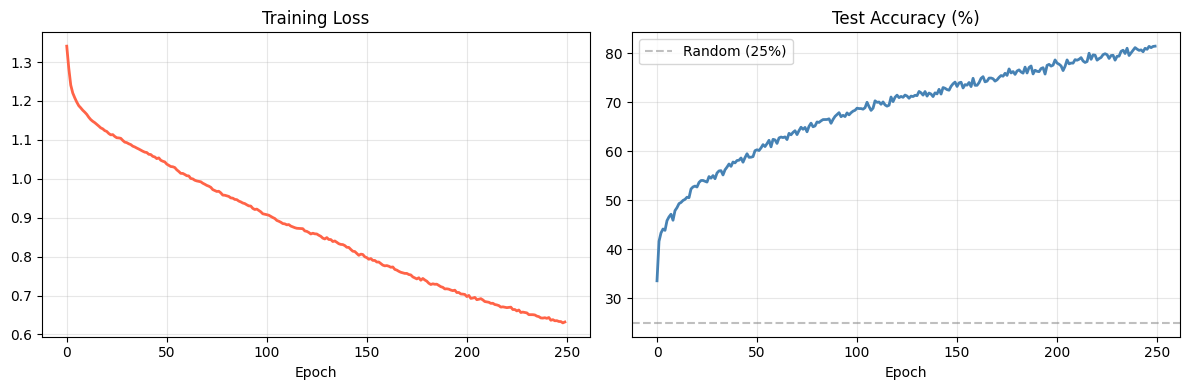

Saved training_curves.png


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='tomato', lw=2)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.grid(True, alpha=0.3)

ax2.plot([a*100 for a in test_accs], color='steelblue', lw=2)
ax2.axhline(25, color='gray', ls='--', alpha=0.5, label='Random (25%)')
ax2.set_title('Test Accuracy (%)')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Saved training_curves.png')

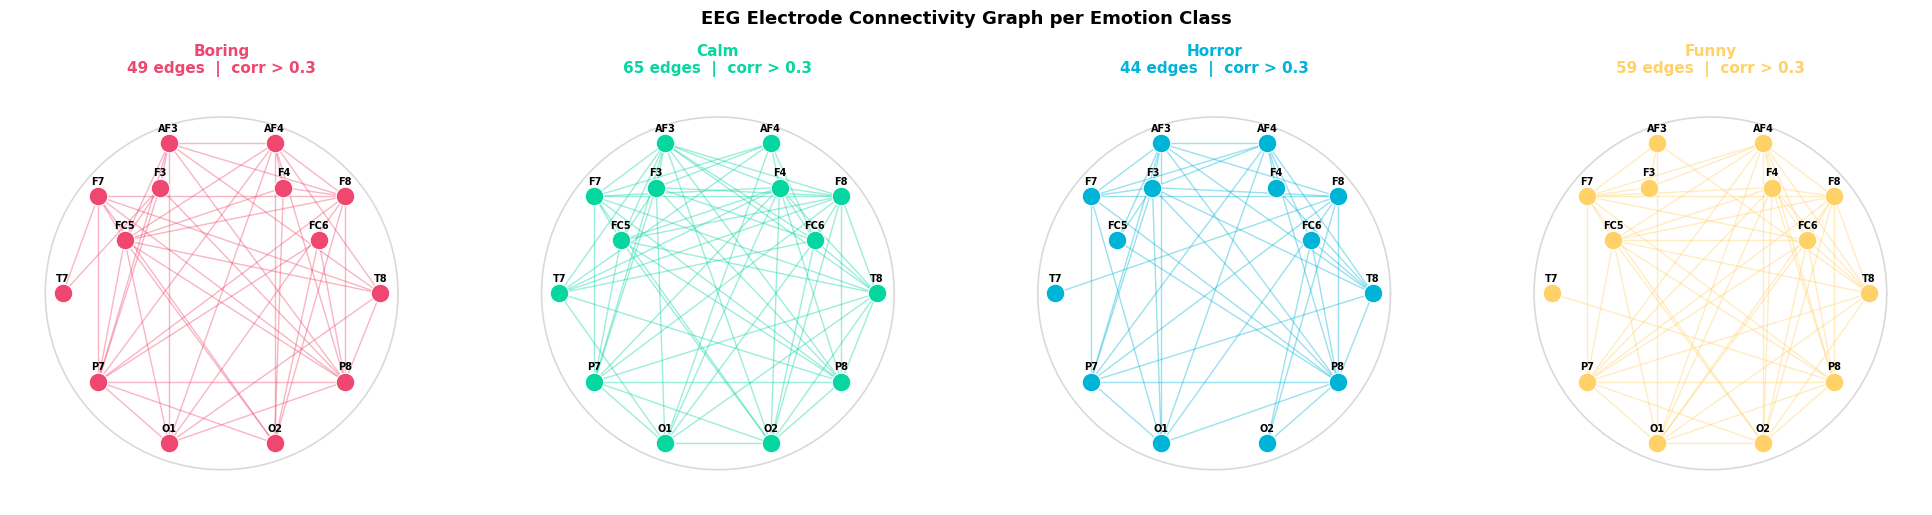

Saved class_graphs.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ELECTRODE_POS = {
    'AF3':(-0.3, 0.85), 'AF4':(0.3, 0.85),
    'F7': (-0.7, 0.55),  'F3':(-0.35, 0.6), 'F4':(0.35, 0.6), 'F8':(0.7, 0.55),
    'FC5':(-0.55, 0.3),  'FC6':(0.55, 0.3),
    'T7': (-0.9, 0),     'T8':(0.9, 0),
    'P7': (-0.7,-0.5),   'P8':(0.7,-0.5),
    'O1': (-0.3,-0.85),  'O2':(0.3,-0.85)
}

CORR_THRESHOLD = 0.3

def build_correlation_adjacency(window, threshold=CORR_THRESHOLD):
    n = window.shape[1]
    adj = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                corr, _ = pearsonr(window[:, i], window[:, j])
                if abs(corr) > threshold:
                    adj[i][j] = 1.0
    adj += np.eye(n)
    return adj


class_windows = {}
for fi in csv_files:
    label = fi['label']
    if label not in class_windows:
        df   = pd.read_csv(fi['path'])
        cols = [c for c in CHANNELS if c in df.columns]
        data = df[cols].values[:128]
        if data.shape[0] == 128:
            class_windows[label] = data
    if len(class_windows) == 4:
        break

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#EF476F', '#06D6A0', '#00B4D8', '#FFD166']   # one per emotion

for label in range(4):
    ax  = axes[label]
    window = class_windows[label]
    adj = build_correlation_adjacency(window)

    t = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(t), np.sin(t), 'k-', lw=1.2, alpha=0.15)

    # edges
    edge_count = 0
    for i, ci in enumerate(CHANNELS):
        for j, cj in enumerate(CHANNELS):
            if i < j and adj[i][j] > 0:
                x1, y1 = ELECTRODE_POS[ci]
                x2, y2 = ELECTRODE_POS[cj]
                ax.plot([x1, x2], [y1, y2],
                        color=colors[label], alpha=0.4, lw=1.0)
                edge_count += 1

    # nodes
    for ch in CHANNELS:
        x, y = ELECTRODE_POS[ch]
        ax.scatter(x, y, s=180, c=colors[label], zorder=5,
                   edgecolors='white', linewidths=0.8)
        ax.annotate(ch, (x, y), xytext=(0, 8),
                    textcoords='offset points',
                    ha='center', fontsize=7, fontweight='bold')

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'{EMOTION_NAMES[label]}\n{edge_count} edges  |  corr > {CORR_THRESHOLD}',
                 fontsize=11, fontweight='bold', color=colors[label])

plt.suptitle('EEG Electrode Connectivity Graph per Emotion Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved class_graphs.png')